In [1]:
import pandas as pd
import duckdb
from google.colab import userdata
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import json
import os
import warnings
warnings.filterwarnings('ignore')

print("Loading data from Hugging Face warehouse...")

# Connect
HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")
con.execute(f"""
    CREATE SECRET hf_token (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    );
""")

# Load dim_content
dim_content = con.execute("""
    SELECT
        content_hash_id,
        content_created_date,
        content_type
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet')
""").fetchdf()

print(f"Loaded dim_content: {len(dim_content)} rows")

Loading data from Hugging Face warehouse...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded dim_content: 519606 rows


In [3]:
# Calculate content_age_days
dim_content['content_created_date'] = pd.to_datetime(dim_content['content_created_date'])
reference_date = pd.Timestamp('2026-03-31')
dim_content['content_age_days'] = (reference_date - dim_content['content_created_date']).dt.days

# Load fact data
fact_data = con.execute("""
    SELECT
        content_hash_id,
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')
    WHERE report_date BETWEEN '2026-03-01' AND '2026-03-31'
        AND gsc_impressions >= 100
    LIMIT 100000
""").fetchdf()

print(f"Loaded fact_data: {len(fact_data)} rows")

# Merge
data = fact_data.merge(dim_content[['content_hash_id', 'content_age_days', 'content_type']], on='content_hash_id', how='inner')
print(f"After merge: {len(data)} rows")

# Calculate target
def expected_ctr(position):
    if position <= 3:
        return 0.0048
    elif position <= 5:
        return 0.0041
    elif position <= 10:
        return 0.0031
    else:
        return 0.0018

data['expected_ctr'] = data['gsc_avg_position'].apply(expected_ctr)
data['actual_ctr'] = data['gsc_clicks'] / data['gsc_impressions']
data['ctr_gap'] = data['expected_ctr'] - data['actual_ctr']

# Remove outliers
data = data[data['ctr_gap'] < data['ctr_gap'].quantile(0.99)]
data = data[data['ctr_gap'] > data['ctr_gap'].quantile(0.01)]
print(f"After removing outliers: {len(data)} rows")

data['baseline_score'] = data['ctr_gap'] * data['gsc_impressions']


data['position_tier'] = pd.cut(data['gsc_avg_position'],
                               bins=[-1, 3, 5, 10, 100],
                               labels=['top_3', 'page_1', 'page_3_5', 'deep'])

data['impression_tier'] = pd.cut(data['gsc_impressions'],
                                 bins=[0, 500, 1000, 5000, 100000],
                                 labels=['low', 'medium', 'high', 'very_high'])

# REMOVED: ctr_ratio (this was the leakage!)
data['pos_impression'] = data['gsc_avg_position'] * data['gsc_impressions']

data['age_tier'] = pd.cut(data['content_age_days'],
                          bins=[0, 90, 180, 365, 10000],
                          labels=['new', 'recent', 'medium', 'old'])

data['log_impressions'] = np.log1p(data['gsc_impressions'])
data['log_age'] = np.log1p(data['content_age_days'])

# One-hot encode
data = pd.get_dummies(data, columns=['content_type', 'position_tier', 'impression_tier', 'age_tier'], drop_first=True)

# Features (NO ctr_ratio, NO gsc_clicks)
features = [
    'gsc_impressions',
    'gsc_avg_position',
    'content_age_days',
    'pos_impression',
    'log_impressions',
    'log_age'
] + [col for col in data.columns if col.startswith('content_type_') or
      col.startswith('position_tier_') or
      col.startswith('impression_tier_') or
      col.startswith('age_tier_')]

features = [f for f in features if f in data.columns]

X = data[features]
y = data['ctr_gap']
baseline = data['baseline_score'].values

print(f"Features: {len(features)} features")

X_train, X_test, y_train, y_test, baseline_train, baseline_test = train_test_split(
    X, y, baseline, test_size=0.3, random_state=42
)

print(f"Train: {len(X_train)} pages, Test: {len(X_test)} pages")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded fact_data: 100000 rows
After merge: 100000 rows
After removing outliers: 88327 rows
Features: 17 features
Train: 61828 pages, Test: 26499 pages


In [4]:
#GRADIENT BOOSTING

model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    min_samples_split=20,
    random_state=42
)

print("\nTraining Gradient Boosting...")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

model_mae = mean_absolute_error(y_test, y_pred)
model_r2 = r2_score(y_test, y_pred)

model_pred_scaled = y_pred * data.loc[X_test.index, 'gsc_impressions'].values
model_mae_scaled = mean_absolute_error(baseline_test, model_pred_scaled)

print("Results Summary")
print(f"Model MAE: {model_mae:.6f}")
print(f"Model R2: {model_r2:.4f}")
print(f"Model MAE (scaled to baseline): {model_mae_scaled:.6f}")


Training Gradient Boosting...
Results Summary
Model MAE: 0.003047
Model R2: 0.1559
Model MAE (scaled to baseline): 0.924712


In [5]:
# Feature importance
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features:")
print(importance.head(10))

# Recommendations
data['predicted_gap'] = model.predict(X)
data['opportunity_score'] = data['predicted_gap'] * data['gsc_impressions']

def get_reason(row):
    if row['gsc_avg_position'] <= 3:
        tier = 'top_3'
    elif row['gsc_avg_position'] <= 5:
        tier = 'page_1'
    elif row['gsc_avg_position'] <= 10:
        tier = 'page_3_5'
    else:
        tier = 'deep'
    return f'CTR_gap_{tier}_{row["ctr_gap"]:.3f}'

data['reason'] = data.apply(get_reason, axis=1)
data['action'] = 'Review title and meta description'

recommendations = data.sort_values('opportunity_score', ascending=False)

print("\nTop 10 Pages to Review:")
top = recommendations.head(10)
for i, row in top.iterrows():
    print(f"{i+1}. {row['content_hash_id'][:20]}... | Position: {row['gsc_avg_position']:.1f} | Gap: {row['ctr_gap']:.4f} | Score: {row['opportunity_score']:.0f}")

# Save outputs
os.makedirs('work/outputs', exist_ok=True)
recommendations.to_csv('work/outputs/capstone_recommendations.csv', index=False)

os.makedirs('work/outputs/charts', exist_ok=True)


Top 10 Features:
                         feature  importance
1               gsc_avg_position    0.499798
5                        log_age    0.134316
2               content_age_days    0.121959
0                gsc_impressions    0.089491
4                log_impressions    0.077726
3                 pos_impression    0.064221
14               age_tier_recent    0.005107
15               age_tier_medium    0.002094
7   content_type_keyword article    0.002021
9         position_tier_page_3_5    0.001247

Top 10 Pages to Review:
10360. content_945d6ff91386... | Position: 8.6 | Gap: 0.0031 | Score: 139
60087. content_1642f339bd6e... | Position: 4.1 | Gap: 0.0041 | Score: 94
10322. content_60b99970e55b... | Position: 3.9 | Gap: 0.0040 | Score: 61
10278. content_0c5606abaaab... | Position: 4.1 | Gap: 0.0041 | Score: 52
50762. content_6a9c79f55413... | Position: 1.6 | Gap: 0.0046 | Score: 43
10254. content_0bca6d9a85a9... | Position: 7.5 | Gap: 0.0031 | Score: 31
60076. content_34a70fea

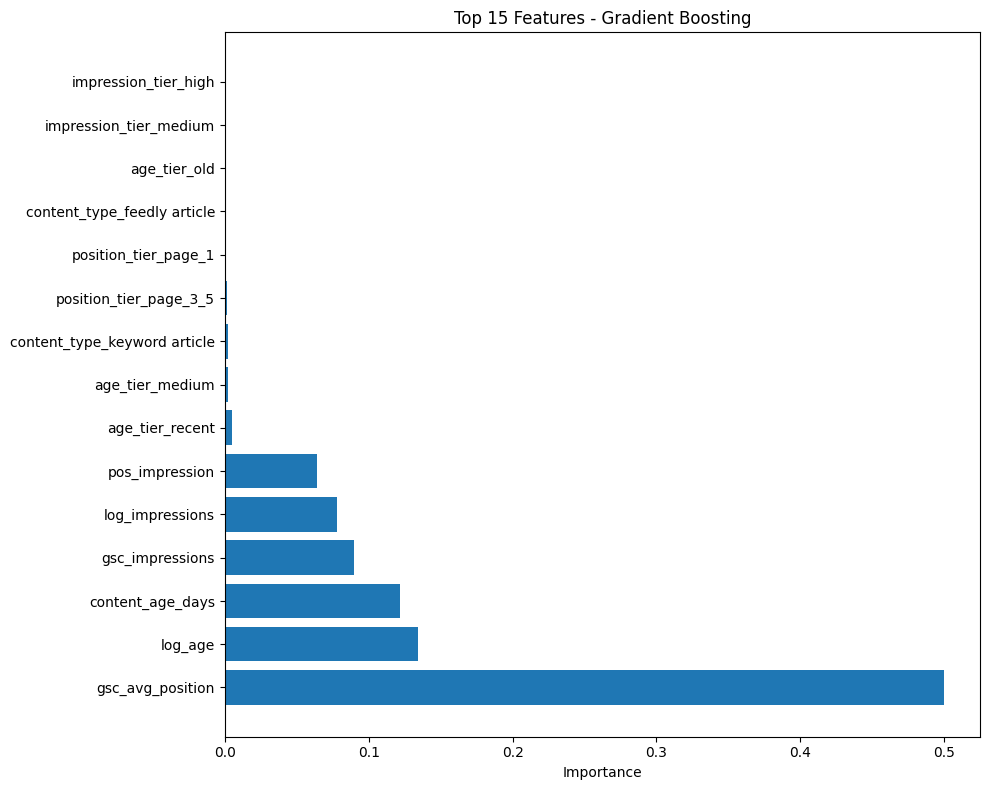

In [6]:
plt.figure(figsize=(10, 8))
plt.barh(importance['feature'][:15], importance['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Features - Gradient Boosting')
plt.tight_layout()
plt.savefig('work/outputs/charts/feature_importance.png', dpi=150)


Outputs saved:
  - work/outputs/capstone_recommendations.csv
  - work/outputs/model_results.json
  - work/outputs/charts/feature_importance.png
  - work/outputs/charts/actual_vs_predicted.png


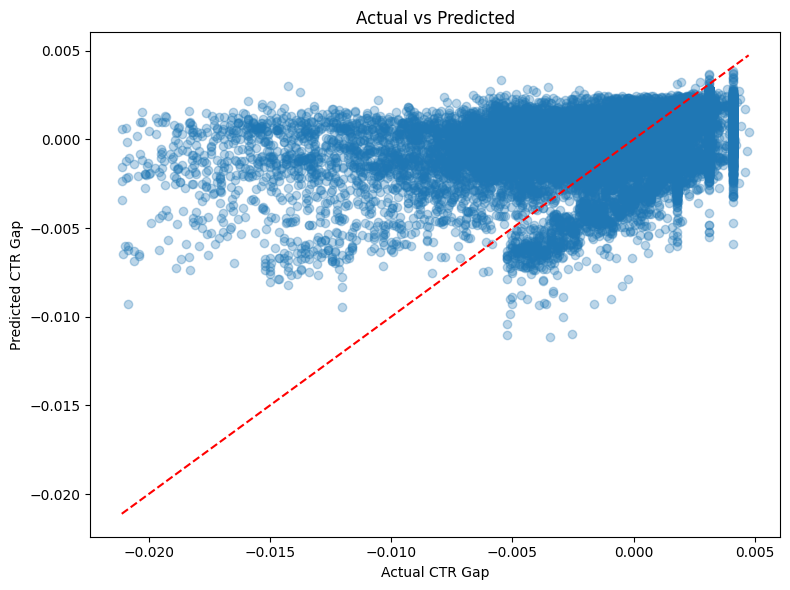

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual CTR Gap')
plt.ylabel('Predicted CTR Gap')
plt.title('Actual vs Predicted')
plt.tight_layout()
plt.savefig('work/outputs/charts/actual_vs_predicted.png', dpi=150)

results = {
    'model_mae': model_mae,
    'model_r2': model_r2,
    'model_mae_scaled': model_mae_scaled,
    'feature_importance': dict(zip(importance['feature'][:10], importance['importance'][:10]))
}

with open('work/outputs/model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nOutputs saved:")
print("  - work/outputs/capstone_recommendations.csv")
print("  - work/outputs/model_results.json")
print("  - work/outputs/charts/feature_importance.png")
print("  - work/outputs/charts/actual_vs_predicted.png")